In [ ]:
import numpy as np # for mathematical caluclations
import pandas as pd
from datetime import datetime  # to access datetime
import scipy.stats as stats

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # for interactive plotting
import plotly.graph_objects as go # for interactive plotting

# set the plot style in matplotlib to ggplot and the firgure size to 15x5## Augmented Dickey Fuller Test for Assessing Stationarity
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15,5)

# for ingnoring warnings
import warnings # to ignore warning
warnings.filterwarnings('ignore')

# for ingnoring warnings
import warnings # to ignore warning
warnings.filterwarnings('ignore')
from google.colab import files
import io

In [ ]:
uploaded = files.upload()

Saving lpga2022.csv to lpga2022.csv


In [ ]:
data = pd.read_csv(io.BytesIO(uploaded['lpga2022.csv']))


In [ ]:
data.head()

,Golfer,Nation,Region,fairways,fairAtt,fairPct,totPutts,totRounds,avePutts,greenReg,totPrize,events,driveDist,sandSaves,sandAtt,sandPct
0,A Lim Kim,Republic of Korea,Asia,962,1395,68.96,3052,108,30.22,74.4,747851,29,274.74,43,95,45.26
1,Aditi Ashok,India,Asia,795,996,79.82,2104,79,29.22,63.0,178900,26,235.10,53,94,56.38
2,Agathe Laisne,France,Europe,412,561,73.44,1248,41,30.44,64.9,41937,18,254.66,29,62,46.77
3,Alana Uriell,United States,North America,510,729,69.96,1575,55,29.72,65.3,66506,21,269.51,43,95,45.26
4,Albane Valenzuela,Switzerland,Europe,756,1074,70.39,2376,81,30.46,70.7,340107,24,265.21,27,74,36.49


In [ ]:
data.describe()

,fairways,fairAtt,fairPct,totPutts,totRounds,avePutts,greenReg,totPrize,events,driveDist,sandSaves,sandAtt,sandPct
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,1.580000e+02,158.000000,158.000000,158.000000,158.000000,158.000000
mean,624.468354,844.702532,73.671962,1837.006329,64.721519,30.082342,68.863291,5.225807e+05,20.474684,257.143671,32.563291,70.803797,45.283608
std,202.380850,256.578603,5.971336,548.114388,19.366355,0.598020,3.947399,6.667042e+05,4.532542,9.318077,11.665963,20.039597,7.766594
min,224.000000,317.000000,56.210000,722.000000,25.000000,28.460000,57.000000,3.185000e+03,10.000000,235.100000,5.000000,25.000000,19.230000
25%,464.250000,655.250000,69.840000,1429.500000,49.250000,29.722500,66.225000,9.653925e+04,18.000000,250.757500,24.000000,58.250000,40.722500
50%,626.000000,875.500000,73.905000,1919.500000,65.500000,30.010000,68.900000,2.626170e+05,21.000000,257.490000,32.000000,73.000000,45.715000
75%,784.750000,1049.500000,77.387500,2274.250000,79.750000,30.447500,71.500000,7.411720e+05,24.000000,263.590000,41.000000,85.750000,50.000000
max,1090.000000,1395.000000,87.250000,3052.000000,108.000000,31.670000,77.700000,4.364403e+06,29.000000,279.250000,63.000000,127.000000,66.250000


In [ ]:
data['putts_per_hole'] = data['avePutts'] / 18

In [ ]:
data['putts_per_hole']

,putts_per_hole
0,1.678889
1,1.623333
2,1.691111
3,1.651111
4,1.692222
...,...
153,1.581111
154,1.701667
155,1.662222
156,1.626667


In [ ]:
data['avg_prize_per_round'] = data['totPrize'] / data['totRounds']

In [ ]:
data['avg_prize_per_round']

,avg_prize_per_round
0,6924.546296
1,2264.556962
2,1022.853659
3,1209.200000
4,4198.851852
...,...
153,1182.637931
154,2632.534884
155,2471.493506
156,8787.431818


In [ ]:
uploaded = files.upload()

Saving wincount_lpga.csv to wincount_lpga.csv


In [ ]:
data_w = pd.read_csv(io.BytesIO(uploaded['wincount_lpga.csv']))


In [ ]:
# LEFT JOIN (default) - Keeps only matching IDs
merged_df = pd.merge(data, data_w, on='Golfer', how='left')
merged_df.fillna(0, inplace=True)
merged_df[merged_df['Golfer'] == "Lydia Ko"]

data = merged_df

In [ ]:
numeric_data = data.select_dtypes(include=['number'])  # Numeric columns


for col in numeric_data.columns:
    if col != 'totPrize':
        fig = px.scatter(data, x=col, y='totPrize',
                         title=f'Scatter Plot of {col} vs. Total Prize',
                         labels={col: col, 'totPrize': 'Total Prize'},
                         hover_name="Golfer",
                         color="Golfer",
                         size="totPrize",
                         opacity=0.7)

        # Adjust graph size to be more compact
        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Total Prize",
            showlegend=True,
            width=1200,
            height=700
        )

        fig.show()


It seems that most of these scatter plots don't have very clear correlations. The couple that have a bit more of a trend would be green regulations which are positively correlated, sand percentage which is negatively correlated and putts per hole in which Lydia Ko (the player with highest earnings) had the lowest putts per hole average.

In [ ]:
numeric_data = data.select_dtypes(include=['number'])  # Numeric columns

### 1. Scatter Plots for Numeric Columns vs. 'avg_prize_per_round'
for col in numeric_data.columns:
    if col != 'avg_prize_per_round':  # Exclude 'avg_prize_per_round' itself
        fig = px.scatter(data, x=col, y='avg_prize_per_round',
                         title=f'Scatter Plot of {col} vs. Avg Prize per Round',
                         labels={col: col, 'avg_prize_per_round': 'Avg Prize per Round'},
                         hover_name="Golfer",  # Show golfer name on hover
                         color="Golfer",
                         size="totPrize",# Assign unique colors to each golfer
                         opacity=0.7)  # Slightly reduce transparency for better visibility

        # Adjust graph size to be more compact
        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Avg Prize per Round",
            showlegend=True,
            width=1200,
            height=700
        )

        fig.show()

It seems that most of these scatter plots don't have very clear correlations. The couple that have a bit more of a trend would be green regulations which are positively correlated and sand percentage which is negatively correlated.

In [ ]:
import plotly.express as px

# Selecting numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Creating box plots for each numeric column except 'avg_prize_per_round'
for col in numeric_data.columns:
    if col != 'avg_prize_per_round':
        fig = px.box(data, x=col, title=f'Box Plot of {col}')
        fig.update_layout(
            xaxis_title=col,
            width=900,
            height=600
        )
        fig.show()

 I then created some boxplots where we saw low deviation for putts per round and high deviation among players for driving distance, green regulation and sand saves.

In [ ]:
import plotly.express as px

# Create an interactive histogram
fig = px.histogram(data, x="totPrize", nbins=50,
                   color_discrete_sequence=px.colors.qualitative.Plotly,  # Colorful bars
                   title="Interactive Histogram of Total Prize Money",
                   labels={"totPrize": "Total Prize Money ($)"})

# Update layout for better readability
fig.update_layout(
    xaxis_title="Total Prize Money ($)",
    yaxis_title="Count of Golfers",
    width=1200,
    height=700,
    bargap=0.1,
)

# Show interactive plot
fig.show()

This graph is heavily skewed to the right. This shows that in golf as in many other professional sports the earnings are not distributed very evenly with a couple very well payed athletes and the majority making much less.

In [ ]:
import plotly.express as px
import pandas as pd


# Select only 'nations' and 'region' columns (modify column names as needed)
categorical_cols = ['Nation', 'Region']

for col in categorical_cols:
    if col in data.columns:  # Ensure column exists in DataFrame
        # Count occurrences and sort them in descending order
        category_counts = data[col].value_counts().reset_index()
        category_counts.columns = [col, 'count']

        # Create histogram with categories ordered by frequency
        fig = px.histogram(data, x=col, title=f'Histogram of {col}', text_auto=True,
                           category_orders={col: category_counts[col].tolist()})  # Sort by frequency

        # Update layout for better visualization
        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Frequency",
            bargap=0.2,
            width=1200,
            height=700
        )

        # Show the plot
        fig.show()

In [ ]:
import plotly.express as px
import pandas as pd


# Select only 'nations' and 'region' columns (modify column names as needed)
categorical_cols = ['Nation', 'Region', 'Golfer']
value_col = 'avg_prize_per_round'

for col in categorical_cols:
    if col in data.columns:
        # Group by category and sum avgPrize money
        category_sums = round(data.groupby(col)[value_col].mean().reset_index(),-2)
        category_sums = category_sums.sort_values(by=value_col, ascending=False)  # Sort by sum of avgPrize

        # Create histogram with categories ordered by total avgPrize money
        fig = px.bar(category_sums, x=col, y=value_col,
                     title=f'Average {value_col} by {col}', text_auto=True)

        # Update layout for better visualization
        fig.update_layout(
            xaxis_title=col,
            yaxis_title=f"Average {value_col}",
            width=1200,
            height=700,
            bargap=0.2
        )

        # Show the plot
        fig.show()

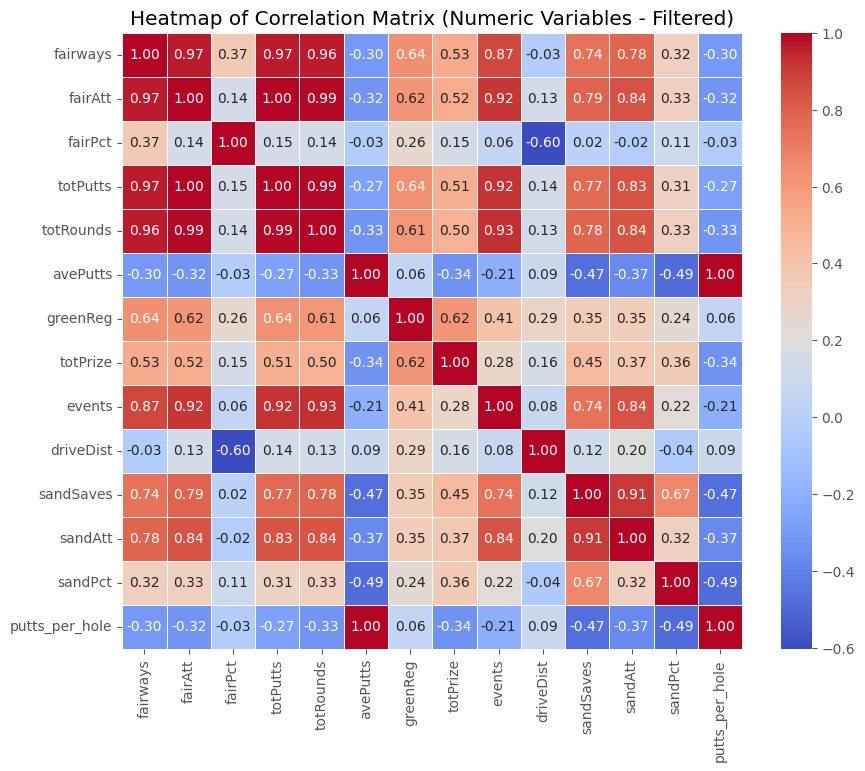

In [ ]:

numeric_data = data.select_dtypes(include=['number']).drop(columns=['avg_prize_per_round', 'OfficialWins_x', 'OfficialWins_y'], errors='ignore')

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Title and display
plt.title("Heatmap of Correlation Matrix (Numeric Variables - Filtered)")
plt.show()

**Strongest Positive Correlations**

Events (0.62): More events played significantly correlate with higher total prize earnings, likely due to increased opportunities to win.
GreenReg (0.45): Hitting more greens in regulation shows a moderate positive correlation, suggesting that approach play influences prize money.
SandSaves (0.45): Successful bunker recovery has a moderate link to higher earnings, implying that short game skills contribute to performance.

**Moderate Positive Correlations**

Fairways (0.53) & FairAtt (0.52): Driving accuracy correlates moderately with total earnings, indicating that keeping the ball in play is beneficial.
TotRounds (0.51): More rounds played also moderately impact total prize, reinforcing the idea that increased participation leads to more earnings.

**Negative Correlations**

AvePutts (-0.34) & TotPutts (-0.34): More putts per round and total putts are negatively correlated with prize earnings, suggesting that better putting efficiency (fewer putts) is crucial for success.
Putts_per_hole (-0.34): Similarly, higher putting averages per hole indicate weaker performance.

In [ ]:
fig = px.scatter(data, x="fairPct", y="driveDist",
                 color="Golfer",  # Assign colors based on the golfer
                 size="totPrize",
                 hover_name="Golfer",
                 title="Driving Distance vs. Accuracy (LPGA 2022)",
                 labels={"fairPct": "Driving Accuracy (%)",
                         "driveDist": "Driving Distance (yards)",
                         "totPrize": "Total Prize Money ($)"})

# Adjust marker transparency and layout
fig.update_traces(marker=dict(opacity=0.7))  # Keep transparency for visibility
fig.update_layout(
    xaxis_title="Driving Accuracy (%)",
    yaxis_title="Driving Distance (yards)",
    width=1200,
    height=700
)

fig.show()

It seems that driving accuracy goes up as the driving distance becomes shorter suggesting that having a long drive is actually not helpful in the long run. It is also interesting to see that Lydia Ko who collected the most prize money in 2022 seems to have a low driving accuracy relative to her driving distance compared to other players which could suggest that driving accuracy is actually not as important as one might think.

# Statistical Analysis

T-Test: Splitting players by prize money amount

Green Regulation

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 500000]['greenReg']
low_earners = data[data['totPrize'] <= 500000]['greenReg']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(10.827410929345076, 6.423998582040538e-20)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 1000000]['greenReg']
low_earners = data[data['totPrize'] <= 1000000]['greenReg']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(8.931000862052871, 5.584378325352778e-12)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['OfficialWins_x'] > 0]['greenReg']
low_earners = data[data['OfficialWins_x'] <= 0]['greenReg']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(6.213613955657468, 2.2686737717131774e-07)

Fairway PCT

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 500000]['fairPct']
low_earners = data[data['totPrize'] <= 500000]['fairPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(3.0363297315443836, 0.002936360015492405)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 1000000]['fairPct']
low_earners = data[data['totPrize'] <= 1000000]['fairPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(2.4747600806632333, 0.01727722389651116)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['OfficialWins_x'] > 0]['fairPct']
low_earners = data[data['OfficialWins_x'] <= 0]['fairPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(3.0229135496096387, 0.004671645737772051)

Sand PCT

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 500000]['sandPct']
low_earners = data[data['totPrize'] <= 500000]['sandPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(4.078300904926976, 8.341462265500646e-05)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 1000000]['sandPct']
low_earners = data[data['totPrize'] <= 1000000]['sandPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(2.927037025960392, 0.0059564015777946)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['OfficialWins_x'] > 0]['sandPct']
low_earners = data[data['OfficialWins_x'] <= 0]['sandPct']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(3.1259925528353567, 0.0036482629618968033)

Putts Per Hole

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 500000]['putts_per_hole']
low_earners = data[data['totPrize'] <= 500000]['putts_per_hole']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(-4.406366805223124, 2.4281627078292348e-05)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 1000000]['putts_per_hole']
low_earners = data[data['totPrize'] <= 1000000]['putts_per_hole']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(-4.223406192384581, 0.00013307957658544937)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['OfficialWins_x'] > 0]['putts_per_hole']
low_earners = data[data['OfficialWins_x'] <= 0]['putts_per_hole']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(-2.873878069882497, 0.007443505016903044)

Drive Distance

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 500000]['driveDist']
low_earners = data[data['totPrize'] <= 500000]['driveDist']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(2.0081683074994183, 0.047092805546457596)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['totPrize'] > 1000000]['driveDist']
low_earners = data[data['totPrize'] <= 1000000]['driveDist']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(1.4021954321911911, 0.1690045238231358)

In [ ]:
from scipy.stats import ttest_ind

high_earners = data[data['OfficialWins_x'] > 0]['driveDist']
low_earners = data[data['OfficialWins_x'] <= 0]['driveDist']

# Perform the t-test (Welch’s t-test for unequal variances)
t_stat, p_value = ttest_ind(high_earners, low_earners, equal_var=False)
t_stat, p_value

(0.05535690487624958, 0.9561976343432192)

Anova Test

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

high_earners = data[data['totPrize'] > 1000000]['driveDist']
medium_earners = data[(data['totPrize'] > 300000) & (data['totPrize'] <= 1000000)]['driveDist']
low_earners = data[data['totPrize'] <= 300000]['driveDist']

# One-way ANOVA
anova_result = f_oneway(high_earners, medium_earners, low_earners)
print(f"ANOVA Result: F={anova_result.statistic:.4f}, p={anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    df_concat = pd.concat([high_earners, medium_earners, low_earners])
    labels = (['High Earners'] * len(high_earners) +
              ['Medium Earners'] * len(medium_earners) +
              ['Low Earners'] * len(low_earners))

    tukey = pairwise_tukeyhsd(endog=df_concat, groups=labels, alpha=0.05)
    print("\nTukey's HSD Test Results:")
    print(tukey)
else:
    print("\nANOVA is not significant, so no need for Tukey’s HSD test.")



ANOVA Result: F=1.6402, p=0.1973

ANOVA is not significant, so no need for Tukey’s HSD test.


In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

high_earners = data[data['totPrize'] > 1000000]['sandPct']
medium_earners = data[(data['totPrize'] > 300000) & (data['sandPct'] <= 1000000)]['sandPct']
low_earners = data[data['totPrize'] <= 300000]['sandPct']

# One-way ANOVA
anova_result = f_oneway(high_earners, medium_earners, low_earners)
print(f"ANOVA Result: F={anova_result.statistic:.4f}, p={anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    df_concat = pd.concat([high_earners, medium_earners, low_earners])
    labels = (['High Earners'] * len(high_earners) +
              ['Medium Earners'] * len(medium_earners) +
              ['Low Earners'] * len(low_earners))

    tukey = pairwise_tukeyhsd(endog=df_concat, groups=labels, alpha=0.05)
    print("\nTukey's HSD Test Results:")
    print(tukey)
else:
    print("\nANOVA is not significant, so no need for Tukey’s HSD test.")


ANOVA Result: F=15.9873, p=0.0000

Tukey's HSD Test Results:
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1        group2     meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------
High Earners    Low Earners  -6.8483 0.0001 -10.6959 -3.0006   True
High Earners Medium Earners  -1.0068 0.8168    -4.93  2.9164  False
 Low Earners Medium Earners   5.8415    0.0   3.0621  8.6208   True
-------------------------------------------------------------------


High earners are much better at sand saves than low earners with high statistically significant. This is also the case when comparing medium to low earners. This suggests that skill within the bunker is highly valuable in performing well.

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

high_earners = data[data['totPrize'] > 1000000]['putts_per_hole']
medium_earners = data[(data['totPrize'] > 300000) & (data['putts_per_hole'] <= 1000000)]['putts_per_hole']
low_earners = data[data['totPrize'] <= 300000]['putts_per_hole']

# One-way ANOVA
anova_result = f_oneway(high_earners, medium_earners, low_earners)
print(f"ANOVA Result: F={anova_result.statistic:.4f}, p={anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    df_concat = pd.concat([high_earners, medium_earners, low_earners])
    labels = (['High Earners'] * len(high_earners) +
              ['Medium Earners'] * len(medium_earners) +
              ['Low Earners'] * len(low_earners))

    tukey = pairwise_tukeyhsd(endog=df_concat, groups=labels, alpha=0.05)
    print("\nTukey's HSD Test Results:")
    print(tukey)
else:
    print("\nANOVA is not significant, so no need for Tukey’s HSD test.")


ANOVA Result: F=17.3516, p=0.0000

Tukey's HSD Test Results:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1        group2     meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
High Earners    Low Earners   0.0329    0.0  0.0168  0.049   True
High Earners Medium Earners   0.0092 0.3821 -0.0072 0.0256  False
 Low Earners Medium Earners  -0.0236    0.0 -0.0353 -0.012   True
-----------------------------------------------------------------


The ANOVA test confirms a statistically significant difference in putts per hole across earnings groups (p = 0.0000). High earners take significantly more putts per hole than low earners (p = 0.000), while medium earners also putt more than low earners (p = 0.000). However, there is no significant difference between high and medium earners (p = 0.3821). Surprisingly, low earners have the fewest putts per hole, contradicting the assumption that fewer putts lead to higher earnings. This suggests that higher earners may take more aggressive putts or rely more on birdie opportunities, whereas low earners may focus on conservative play and avoiding three-putts

Regression Analysis

In [ ]:
import statsmodels.api as sm
numeric_data = data.select_dtypes(include=['number'])

# Define dependent (Y) and independent (X) variables
y = numeric_data['totPrize']  # Target variable
X = numeric_data.drop(columns=['totPrize','OfficialWins_y', 'OfficialWins_x', 'avg_prize_per_round'])  # Remove Y variable from predictors

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               totPrize   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     19.07
Date:                Wed, 19 Feb 2025   Prob (F-statistic):           2.76e-24
Time:                        17:42:31   Log-Likelihood:                -2267.7
No. Observations:                 158   AIC:                             4561.
Df Residuals:                     145   BIC:                             4601.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.288e+06   5.97e+06      0.

This OLS regression model explains 61.2% of the variance in totPrize (R² = 0.612). greenReg (p = 0.000) is the only highly significant variable positively impacting total prize money. sandSaves (p = 0.015), sandAtt (p = 0.042), and sandPct (p = 0.032) are also statistically significant but have smaller effects. events (p = 0.060) is marginally significant, while most other variables (fairways, totPutts, putts_per_hole, driveDist) are not significant. Multicollinearity is a concern (Condition Number = 5.11e+18), and residuals are not normally distributed (JB test p ≈ 0.000). The Durbin-Watson statistic (1.748) suggests mild autocorrelation.

In [ ]:
import statsmodels.api as sm
numeric_data = data.select_dtypes(include=['number'])

# Define dependent (Y) and independent (X) variables
y = numeric_data['avg_prize_per_round']  # Target variable
X = numeric_data.drop(columns=['avg_prize_per_round', 'OfficialWins_y', 'totPrize', 'OfficialWins_x'])  # Remove Y variable from predictors

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the summary table
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     avg_prize_per_round   R-squared:                       0.599
Model:                             OLS   Adj. R-squared:                  0.565
Method:                  Least Squares   F-statistic:                     18.02
Date:                 Wed, 19 Feb 2025   Prob (F-statistic):           3.01e-23
Time:                         18:16:08   Log-Likelihood:                -1580.6
No. Observations:                  158   AIC:                             3187.
Df Residuals:                      145   BIC:                             3227.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           5.531e+04   7.72e+

This OLS regression model explains 59.9% of the variance in average prize per round, indicating a moderate fit. The strongest positive predictor is greens in regulation (p = 0.000), showing that players who hit more greens tend to earn significantly more per round. Sand saves (p = 0.022) also contribute positively, but excessive sand play appears detrimental, as sand percentage (p = 0.042) and sand attempts (p = 0.083) negatively correlate with earnings. Total rounds played (p = 0.039) and events participated in (p = 0.078) both have negative effects, suggesting that higher participation does not necessarily lead to better per-round earnings. Several factors, including fairways, fairway attempts, putts, and driving distance, do not show strong significance.

In [ ]:
import statsmodels.api as sm
numeric_data = data.select_dtypes(include=['number'])

# Define dependent (Y) and independent (X) variables
y = numeric_data['OfficialWins_x']  # Target variable
X = numeric_data.drop(columns=['OfficialWins_x', 'OfficialWins_y', 'totPrize', 'avg_prize_per_round'])  # Remove Y variable from predictors

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         OfficialWins_x   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     4.320
Date:                Wed, 19 Feb 2025   Prob (F-statistic):           7.52e-06
Time:                        18:16:30   Log-Likelihood:                -92.120
No. Observations:                 158   AIC:                             210.2
Df Residuals:                     145   BIC:                             250.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.1144      6.255      0.

This OLS regression model attempts to predict Official Wins (OfficialWins_x) but explains only 26.3% of the variance (R² = 0.263), indicating a weak fit. The only significant positive predictor is greens in regulation (p = 0.002), suggesting that hitting more greens is associated with more wins. Sand saves (p = 0.041) also show a small positive effect, implying that successfully recovering from bunkers contributes slightly to winning more tournaments. Most other variables, including fairways, fairway attempts, putting stats, total rounds, events, and driving distance, are not statistically significant, meaning they do not reliably predict official wins.